In [18]:
# WATER QUALITY AND POTABILITY
# The problem of this dataset is that we want to determine the potability of water for human consumption.
# The objective is to assess and predict water potability based on water quality attributes in the column.
# Each row of this dataset represents a water sample with specific attributes, and the column that shows
# 'Potability' indicates whether the water is suitable for human consumption.

EXPLORATORY DATA ANALYSIS(EDA)

Steps in EDA on a Dataset

1. Loading the Data
2. Initial Data Inspection
3. Summary Statistics
4. Missing Values Analysis
5. Data Cleaning
6. Data Visualization

1. Loading the Data

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
# from google colab import drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
data = pd.read_csv('/content/water_potability.csv')
data.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [22]:
data.tail()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1
3275,7.874671,195.102299,17404.177061,7.509306,NaN,327.459760,16.140368,78.698446,2.309149,1


2. Initial Data Inspection of the basic structure and summary of the dataset.

In [23]:
# Display basic information about the dataset
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB
None


In [24]:
data.shape[0]

3276

In [25]:
# Display summary statistics using .describe()
data.describe(include='all')

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


3. Summary Statistics

In [26]:
# Summary statistics for numerical features: The features that have numbers.
numerical_stats = data.describe()
numerical_stats

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [27]:
# The dataset does not contain any categorical features (columns with 'object' dtype).
# Therefore, calling data.describe(include=['O']) will result in a ValueError.
# If categorical features were present, this line would display their summary statistics.
# For now, we will leave this cell blank or add a comment.

4. Missing Values Analysis

Identify the missing values in the dataset.

In [28]:
# Check for missing values
#The .sum()gives the figures for total missing values
missing_values = data.isnull().sum()
print(missing_values)

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


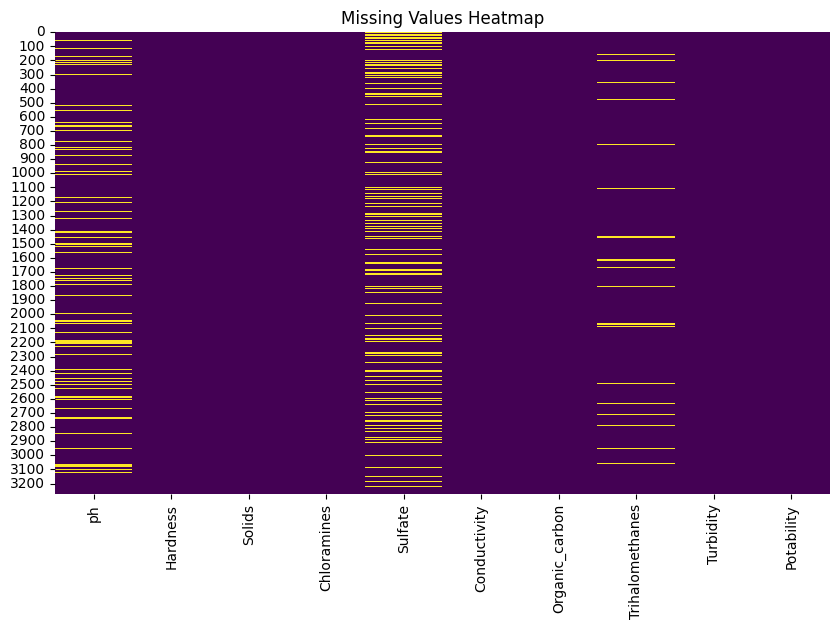

In [29]:
# To get the visualized representation of thr missing values analysis we plot a diagram for it.

plt.figure(figsize=(10,6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

5. Data Cleaning

Handle missing values by imputing or dropping them as apporpriate.

In [30]:
# Since the number of missing values are not so much or are not up to 50% to
# 60% of the dataset we do not drop any column but fill in the missing values using the
# median which is best here instead of the mean because the data is skewed.

# Fill missing values in'pH' with the median
data['ph'].fillna(data['ph'].median(), inplace=True)

# Fill missing values in 'Sulfate' with the median
data['Sulfate'].fillna(data['Sulfate'].median(), inplace=True)

# Fill missing values in 'Trihalomthanes'with the median
data['Trihalomethanes'].fillna(data['Trihalomethanes'].median(), inplace=True)

# Verify that there are no more missing values
print(data.isnull().sum())

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


/tmp/ipykernel_3738/1307283855.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['ph'].fillna(data['ph'].median(), inplace=True)
/tmp/ipykernel_3738/1307283855.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

6. Data Visualization

Create various plots to visualize the data.

Count Plot for Potability

This plot will show the count of whether the water is potable or not.

/tmp/ipykernel_3738/2920482220.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Potability', data=data, palette= 'Set2')


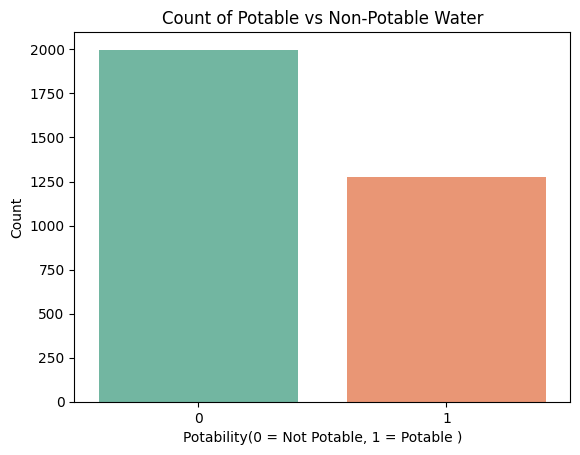

In [31]:
sns.countplot(x='Potability', data=data, palette= 'Set2')
plt.title('Count of Potable vs Non-Potable Water')
plt.xlabel('Potability(0 = Not Potable, 1 = Potable )')
plt.ylabel('Count')
plt.show()

2. Histogram for all Attributes

This creates a histogram for each column to show how values are distributed across all features.

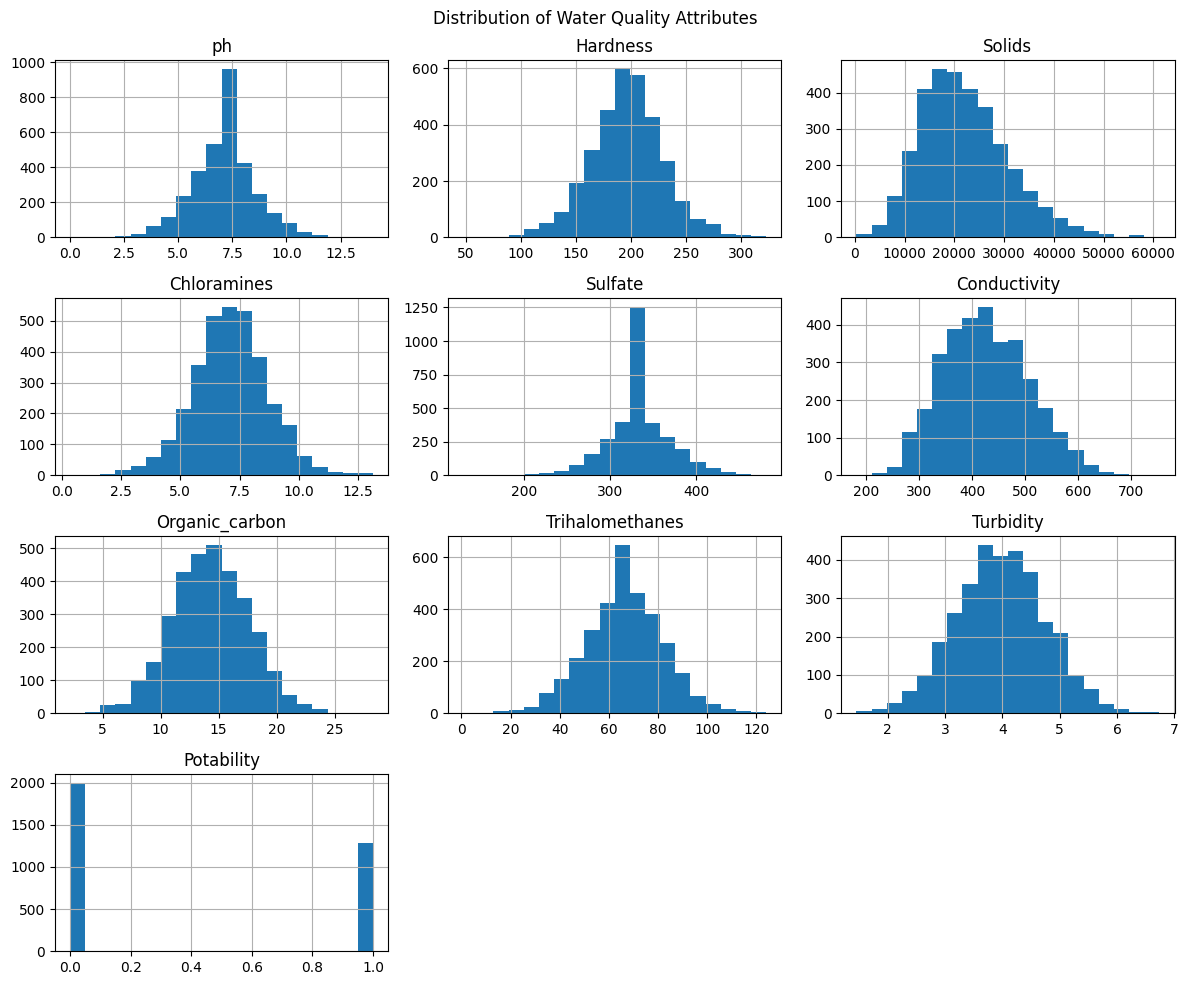

In [32]:
data.hist(figsize=(12, 10), bins=20)
plt.suptitle('Distribution of Water Quality Attributes')
plt.tight_layout()
plt.show()

# This will:
# Create histogram for each column
# Show how values are distributed across all features

3. Box Plot for pH vs Potability

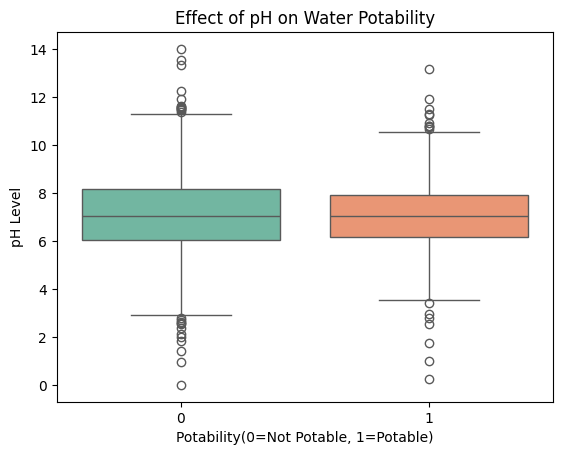

In [51]:
# Box Plot: pH vs Potability
sns.boxplot(x='Potability', y='ph', data=data, palette='Set2')

# Titles
plt.title('Effect of pH on Water Potability')
plt.xlabel('Potability(0=Not Potable, 1=Potable)')
plt.ylabel('pH Level')

plt.show()

In [32]:
# Diagram Explanation
# x ='Potability'- separates the two classes(0=Not Potable, 1=Potable)
# y='pH'- shows the distribution of pH values.
# The boxplot shows the median, quartiles, and possible outliers.
# Easy to compare how pH differs between potable and non-potable water.

4. Box Plot for pH and Chloramines on Potability

 This plot will let you visually see which how pH and Chloramines affect water potability.

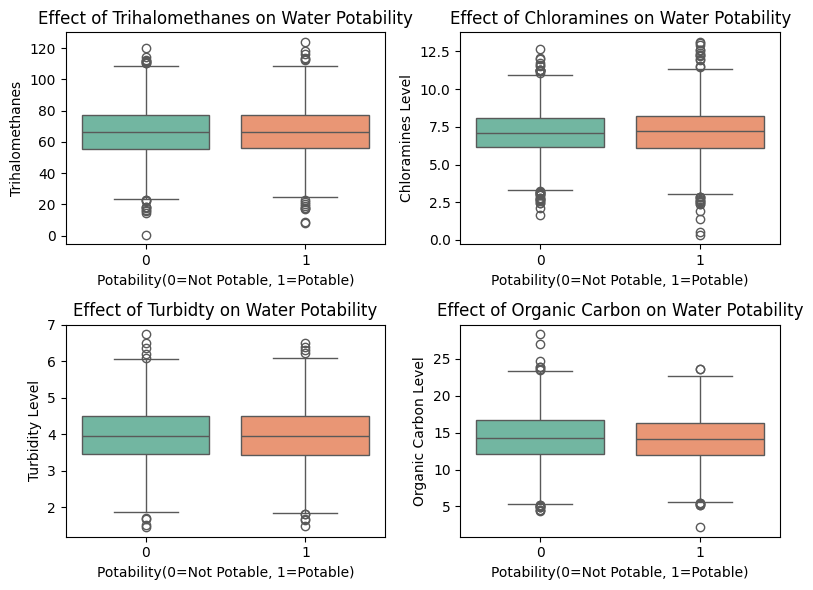

In [52]:
# Create separate plots for all the attributes vs their effect on the potability on water

plt.figure(figsize=(8, 6)) # Adjusted figsize for 2x2 grid

plt.subplot(2,2,1) # First plot in a 2x2 grid
# Corrected: Specify 'y' for the numerical column ('ph') and pass the full 'data' DataFrame.
sns.boxplot(x='Potability', y='Trihalomethanes', data=data, palette='Set2')
plt.title('Effect of Trihalomethanes on Water Potability')
plt.xlabel('Potability(0=Not Potable, 1=Potable)')
plt.ylabel('Trihalomethanes')

plt.subplot(2,2,2) # Second plot
# Corrected: Specify 'y' for the numerical column ('Chloramines') and pass the full 'data' DataFrame.
sns.boxplot(x='Potability', y='Chloramines', data=data, palette='Set2')
plt.title('Effect of Chloramines on Water Potability')
plt.xlabel('Potability(0=Not Potable, 1=Potable)')
plt.ylabel('Chloramines Level')

plt.subplot(2,2,3) # Third plot
sns.boxplot(x='Potability', y='Turbidity', data=data, palette='Set2')
plt.title('Effect of Turbidty on Water Potability')
plt.xlabel('Potability(0=Not Potable, 1=Potable)')
plt.ylabel('Turbidity Level')

plt.subplot(2,2,4) # Fourth plot, changed to subplot and 2x2 grid index
sns.boxplot(x='Potability', y='Organic_carbon', data=data, palette='Set2')
plt.title('Effect of Organic Carbon on Water Potability')
plt.xlabel('Potability(0=Not Potable, 1=Potable)')
plt.ylabel('Organic Carbon Level')
plt.tight_layout()

plt.show()

5. A Scatterplot to show the relationship Between Solids and Conductivity

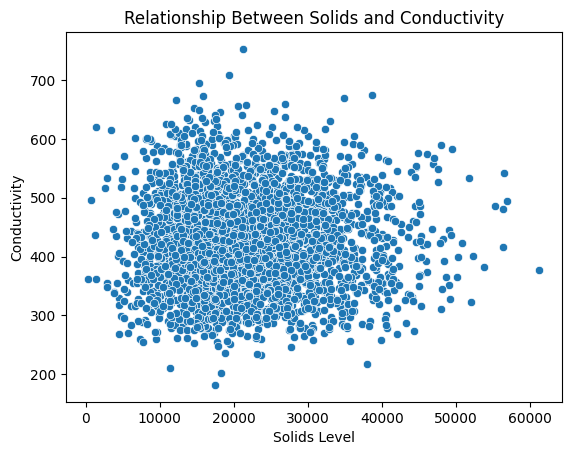

In [53]:
sns.scatterplot(x='Solids', y='Conductivity', data=data, palette='Set2')
plt.title('Relationship Between Solids and Conductivity')
plt.xlabel('Solids Level')
plt.ylabel('Conductivity')
plt.show()

6. Correlation Heatmap of Water Quality

This will show the relationship(correlation) between the features of water quality.

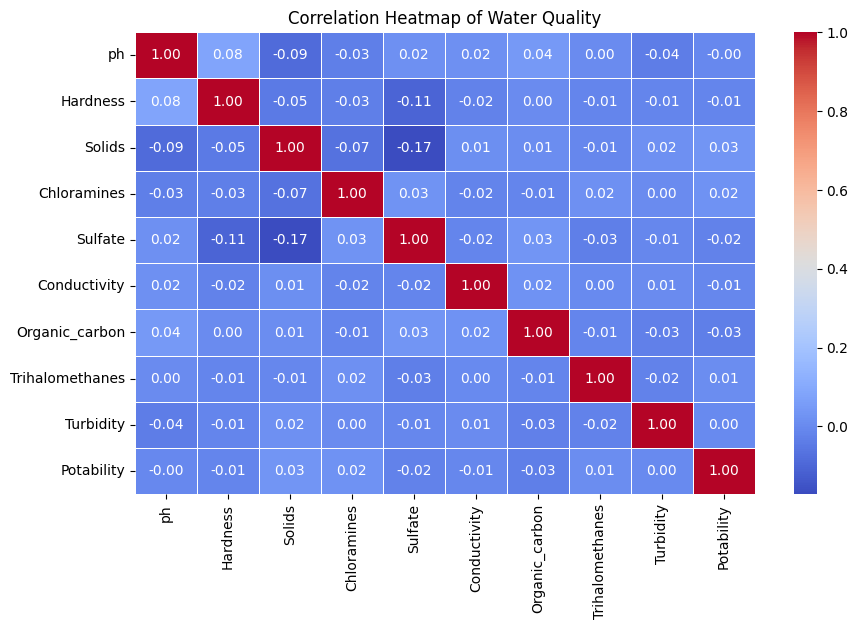

In [54]:
# Set figure size
plt.figure(figsize=(10,6))

# Create the correlation matrix
corr_matrix  = data.corr()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)  # This shows values, 2 decimal places, color style.
plt.title('Correlation Heatmap of Water Quality')
plt.show()


**SUPERVISED LEARNING**

WATER QUALITY AND QUALITY

Problem Statement:

Develop a predictive model to identify whether the water samples collected are potable or not potable for human consumption.

About the Dataset

There are 10 columns/features and 3276 rows/samples.

RowNumber- Corresponds to the record(row) number and has no effect on the output.

pH- The pH level of the water.

Hardness- Water hardness, a measure of mineral content.

Solids- Total dissolved solids in the water.

Cholramines- Cholramines concentration in the water.

Sulfate- Sulfate concentration in the water.

Conductivity- Electrical conductivity of the water.

Orangic_Carbon- Organic Carbon content in the water.

Trihalomethanes- Trihalomethanes concentration in the water.

Turbidity- Turbidity level, a measure of water clarity.

Potability- Target variable; indicates water potability with values 1(potable), and 0(not potable).

KNN

Why K-Nearest Neighbors can be suitable for this dataset is that:

It predicts the potability of water based on similarity to other samples.
Example: if a new water sample has pH, solids, and hardness similar to other potable water samples, KNN will classify it as potable.
It makes no assumptions about data distribution: Unlike Logistics Regression(which assumes linear relationships), KNN is non-parametric. This helps because water quality features may interact non-linearly.

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings('ignore')
from scipy.stats.mstats import winsorize
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb
from scipy.stats import uniform, randint
import scipy.stats as stats
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


In [34]:
 from google.colab import drive

In [35]:
# load Data
data = pd.read_csv('/content/water_potability.csv')
data.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [36]:
data.tail()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1
3275,7.874671,195.102299,17404.177061,7.509306,NaN,327.459760,16.140368,78.698446,2.309149,1


1. DATA INSPECTION

In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [38]:
data.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


2. DATA PREPROCESSING

In [39]:
# SPLIT DATA FIRST ( TO AVOID DATA LEAKAGE)
x = data.drop('Potability', axis=1)
y = data['Potability']

train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.2, random_state=42)

In [40]:
# MEDIAN IMPUTATION: This is done to handle the missing values in the dataset.
# We use SimpleImputer to fill NaNs using the training set's median

imputer = SimpleImputer(strategy='median')
train_x_imputed = pd.DataFrame(imputer.fit_transform(train_x), columns=train_x.columns)
test_x_imputed = pd.DataFrame(imputer.transform(test_x), columns=test_x.columns)


In [41]:
# WINZORIZATION (Handling Outliers)
# We cap top and bottom 5% of values to remove extreme noise

def apply_winzorize(data):
  for col in data.columns:
    # Limits=[0.05, 0.05] caps the 5th and 95th percent:
    data[col] = winsorize(data[col], limits=[0.05,0.05])
    return data

    train_x_win = apply_winzorize(train_x_imputed.copy())
    test_x_win = apply_winzorize(test_x_imputed.copy())



In [42]:
# FEATURE SCALING
#KNN relies on distance; scaling ensures features like 'Solids' don't dominate 'pH'

def apply_winzorize(data):
  for col in data.columns:
    # Limits=[0.05, 0.05] caps the 5th and 95th percent:
    data[col] = winsorize(data[col], limits=[0.05,0.05])
  return data # Corrected indentation for return statement

train_x_win = apply_winzorize(train_x_imputed.copy())
test_x_win = apply_winzorize(test_x_imputed.copy())

scaler = StandardScaler()
train_x_scaled = scaler.fit_transform(train_x_win)
test_x_scaled = scaler.transform(test_x_win)


3. TRAIN THE MODEL USING K-NEAREST NEIGHBOR

In [43]:
# TRAIN THE KNN MODEL
KNN = KNeighborsClassifier(n_neighbors=7)

KNN.fit(train_x_scaled, train_y)


KNeighborsClassifier(n_neighbors=7)

4. EVALUATE THE MODEL

In [44]:
# MODEL EVALUATION
test_prediction = KNN.predict(test_x_scaled)
y_pred_proba = KNN.predict_proba(test_x_scaled)[:,1]
accuracy = accuracy_score(test_y, test_prediction)
print(f'Model Accuracy: {accuracy}')
print(classification_report(test_y, test_prediction))
print(confusion_matrix(test_y, test_prediction))


Model Accuracy: 0.6402439024390244
              precision    recall  f1-score   support

           0       0.69      0.78      0.73       412
           1       0.52      0.40      0.45       244

    accuracy                           0.64       656
   macro avg       0.60      0.59      0.59       656
weighted avg       0.63      0.64      0.63       656

[[323  89]
 [147  97]]


In [45]:
auc_score = roc_auc_score(test_y, y_pred_proba)
print(f'AUC Score: {auc_score:.4f}')

AUC Score: 0.6141


2. DECISION TREE CLASSIFIER USING OOP APPROACH

In [46]:
class WaterPotabilityModel:
    def __init__(self, data):
        self.data = data
        self.imputer = SimpleImputer(strategy='median')
        self.model = DecisionTreeClassifier() # Default model, can be overridden
        self.train_x, self.test_x, self.train_y, self.test_y = (None,) * 4

    def preprocess_data(self, test_size=0.2):
        # 1. Split
        x = self.data.drop('Potability', axis=1)
        y = self.data['Potability']
        self.train_x, self.test_x, self.train_y, self.test_y = train_test_split(
            x, y, test_size=test_size, random_state=42
        )

        # 2. Impute (Median)
        self.train_x = pd.DataFrame(self.imputer.fit_transform(self.train_x), columns=x.columns)
        self.test_x = pd.DataFrame(self.imputer.transform(self.test_x), columns=x.columns)


        # 3. Winzorize(Handling Outliers)
        for col in self.train_x.columns:
          self.train_x[col] = winsorize(self.train_x[col], limits=[0.05, 0.05])
        for col in self.test_x.columns:
          self.test_x[col] = winsorize(self.test_x[col], limits=[0.05, 0.05])

    def train(self, max_depth=None, min_samples_leaf=1):
        # we can pass hyperparameters here to avoid overfitting
        self.model = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        self.model.fit(self.train_x, self.train_y)

    def evaluate(self):
        predictions = self.model.predict(self.test_x)
        probs = self.model.predict_proba(self.test_x)[:,1]

        accuracy = accuracy_score(self.test_y, predictions)
        auc = roc_auc_score(self.test_y, probs)

        print(f'Decision Tree Accuracy: {accuracy:.4f}')
        print(f'Decision Tree AUC Score: {auc:.4f}')
        print(classification_report(self.test_y, predictions))
        print(confusion_matrix(self.test_y, predictions ))
        return accuracy, auc


In [47]:
# Usage
waterpotability = WaterPotabilityModel(data)
waterpotability.preprocess_data()
waterpotability.train(max_depth=10, min_samples_leaf=5)
waterpotability.evaluate()

Decision Tree Accuracy: 0.6250
Decision Tree AUC Score: 0.6394
              precision    recall  f1-score   support

           0       0.67      0.78      0.72       412
           1       0.49      0.36      0.42       244

    accuracy                           0.62       656
   macro avg       0.58      0.57      0.57       656
weighted avg       0.61      0.62      0.61       656

[[321  91]
 [155  89]]


(0.625, np.float64(0.6394487108069393))

RANDOM FOREST CLASSIFIER WITH PROCEDURAL APPROACH

In [48]:
# 1. lOAD DATA
data = pd.read_csv('/content/water_potability.csv')

# 2. TRAIN-TEST SPLIT( DONE FIRST TO PREVENT DATA LEAKAGE)
x = data.drop('Potability', axis=1)
y = data['Potability']
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.2, random_state=42)

# 3. MEDIAN IMPUTATION
# We use SimpleImputer to fill holes in the data using the training median
imputer = SimpleImputer(strategy='median')
train_x = pd.DataFrame(imputer.fit_transform(train_x), columns=x.columns)
test_x = pd.DataFrame(imputer.transform(test_x), columns=x.columns)

# 4. WINSORIZATION (Handle Outliers)
# Cap extreme values at 5% limits  to reduce noise
for col in train_x.columns:
  train_x[col] = winsorize(train_x[col], limits=[0.05, 0.05])
  test_x[col] = winsorize(test_x[col], limits=[0.05, 0.05])

# 5. RANDOM FOREST MODEL
# Using 200 trees and balanced weight to improve performance
RF_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=15,
    random_state=42
)
# 6. TRAIN AND PREDICT
RF_model.fit(train_x, train_y)
y_pred = RF_model.predict(test_x)
y_proba = RF_model.predict_proba(test_x)[:,1]


#7. EVALUATION
print(f'Accuracy: {accuracy_score(test_y, y_pred):.4f}')
print(f'AUC Score: {roc_auc_score(test_y, y_proba):.4f}')
print(classification_report(test_y, y_pred))
print(confusion_matrix(test_y, y_pred))

Accuracy: 0.6738
AUC Score: 0.6794
              precision    recall  f1-score   support

           0       0.69      0.89      0.77       412
           1       0.62      0.31      0.42       244

    accuracy                           0.67       656
   macro avg       0.65      0.60      0.59       656
weighted avg       0.66      0.67      0.64       656

[[366  46]
 [168  76]]


XGBOOST USING OOP APPROACH

In [49]:
class WaterPotabilityModel:
  def __init__(self, data):
    self.data = data
    # No Imputer needed! XGBoost handles NaNs natively
    self.model = None # Initialize model to None, will be set in train()
    self.train_x, self.test_x, self.train_y, self.test_y = [None] * 4
    self.ratio = 1 # Initialize ratio to a default value

  def preprocess_and_split(self):
    x = self.data.drop('Potability', axis=1)
    y = self.data['Potability']

    # 1. The 'Chemical Interaction' feature
    # High Sulfate + High Chloramines often realte to specific water sources
    x['Chemical Interaction'] = x['Sulfate'] * x['Chloramines']

    #2. The 'Safety Ratio'
    # pH and Hardness together often determines if water is corrosive
    x['ph_Hardness_Ratio'] = x['ph'] / (x['Hardness'] + 1e-5)

    # 3. Square important features ( to capture non-linear features)
    x['Sulfate_Sq'] = x['Sulfate'] **2

    # Split first (stratify ensures both sets have the same % of potable water)
    self.train_x, self.test_x, self.train_y, self.test_y = train_test_split(
        x, y, test_size=0.2, stratify=y, random_state=42
    )
    # Calculate ratio after split, using self.train_y
    self.ratio = len(self.train_y[self.train_y == 0]) / len(self.train_y[self.train_y == 1])
    print('Data Split: NaNs preserved for XGBoost to handle.')

  def train(self):
    # Initialize model here, after self.ratio is available
    self.model = xgb.XGBClassifier(
        scale_pos_weight=self.ratio,
        n_estimators=500,
        learning_rate=0.01,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='auc',
        reg_lambda=2.0,
        gamma=0.2,
        random_state=42
    )
    # We pass the data directly with NaNs
    self.model.fit(self.train_x, self.train_y)
    print('Model trained.')


  def evaluate(self):
    # Use predict_proba for AUC
    probs = self.model.predict_proba(self.test_x)[:,1]
    preds = self.model.predict(self.test_x)

    auc = roc_auc_score(self.test_y, probs)
    accuracy = accuracy_score(self.test_y, preds)


    print(f'--- Results---')
    print(f'AUC Score: {auc:.4f}')
    print(f'Accuracy: {accuracy:.4f}')
    print(classification_report(self.test_y, preds))
    print(confusion_matrix(self.test_y, preds))


In [50]:
# Usage
model_obj = WaterPotabilityModel(data)
model_obj.preprocess_and_split()
model_obj.train()
model_obj.evaluate()

Data Split: NaNs preserved for XGBoost to handle.
Model trained.
--- Results---
AUC Score: 0.6832
Accuracy: 0.6631
              precision    recall  f1-score   support

           0       0.71      0.75      0.73       400
           1       0.57      0.53      0.55       256

    accuracy                           0.66       656
   macro avg       0.64      0.64      0.64       656
weighted avg       0.66      0.66      0.66       656

[[300 100]
 [121 135]]
